# DenseNet121 + FourierLayer — javított teljes test evaluation notebook

Ez a verzió automatikusan megkeresi a DenseNet checkpointot több lehetséges útvonalon is, például:

- `DenseNet121_Fourier_final/checkpoints/best_densenet121_fourierlayer.pth`
- `DenseNet121_FourierLayer_final/checkpoints/best_densenet121_fourierlayer.pth`

Ha egyik sem létezik, kilistázza a `/content/drive/MyDrive/Brain MRI/FNO_clas/` alatti mappákat és checkpoint fájlokat, hogy könnyen látszódjon a pontos név.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.fft

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("Torch:", torch.__version__)
print("CUDA elérhető:", torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA elérhető: True


In [3]:
# =========================
# BEÁLLÍTÁSOK
# =========================

BASE_DIR = "/content/drive/MyDrive/Brain MRI/FNO_clas"

# Több lehetséges checkpoint útvonal.
# A notebook automatikusan az első létezőt választja.
DENSENET_CKPT_CANDIDATES = [
    "/content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/checkpoints/best_densenet121_fourierlayer.pth",
    "/content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_FourierLayer_final/checkpoints/best_densenet121_fourierlayer.pth",
    "/content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/checkpoints/best_densenet121_fourier.pth",
    "/content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_FourierLayer_final/checkpoints/best_densenet121_fourier.pth",
]

TEST_DIR = "/content/drive/MyDrive/Brain MRI/dataset/Test"

OUT_DIR = "/content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL"

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 2
SEED = 42

CANONICAL_CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Test folder:", TEST_DIR)

Device: cuda
Test folder: /content/drive/MyDrive/Brain MRI/dataset/Test


In [4]:
# =========================
# CHECKPOINT AUTOMATIKUS KERESÉSE
# =========================

DENSENET_CKPT = None

for candidate in DENSENET_CKPT_CANDIDATES:
    if os.path.exists(candidate):
        DENSENET_CKPT = candidate
        break

if DENSENET_CKPT is None:
    print("Nem találtam checkpointot az előre megadott útvonalakon.")
    print("\nPróbált útvonalak:")
    for c in DENSENET_CKPT_CANDIDATES:
        print(" -", c)

    print("\nFNO_clas mappa tartalma:")
    if os.path.exists(BASE_DIR):
        for root, dirs, files in os.walk(BASE_DIR):
            # Csak checkpoint jellegű fájlokat írunk ki
            ckpt_files = [f for f in files if f.endswith(".pth") or f.endswith(".pt")]
            if ckpt_files:
                print("\nMappa:", root)
                for f in ckpt_files:
                    print("  -", f)
    else:
        print("BASE_DIR nem létezik:", BASE_DIR)

    raise FileNotFoundError(
        "Nem található DenseNet checkpoint. Másold be a pontos .pth útvonalat a DENSENET_CKPT_CANDIDATES listába."
    )

print("Kiválasztott checkpoint:")
print(DENSENET_CKPT)

# OUT_DIR automatikusan a checkpoint projektmappájába kerüljön
PROJECT_DIR = os.path.dirname(os.path.dirname(DENSENET_CKPT))
OUT_DIR = os.path.join(PROJECT_DIR, "test_evaluation_FULL")
os.makedirs(OUT_DIR, exist_ok=True)

print("Output folder:", OUT_DIR)

Kiválasztott checkpoint:
/content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/checkpoints/best_densenet121_fourierlayer.pth
Output folder: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL


In [5]:
# =========================
# ÚTVONALAK ELLENŐRZÉSE
# =========================

if not os.path.exists(DENSENET_CKPT):
    raise FileNotFoundError(f"Checkpoint nem található: {DENSENET_CKPT}")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test mappa nem található: {TEST_DIR}")

print("Checkpoint létezik:", os.path.exists(DENSENET_CKPT))
print("Test mappa létezik:", os.path.exists(TEST_DIR))

print("\nTest mappa tartalma:")
for item in sorted(os.listdir(TEST_DIR)):
    p = os.path.join(TEST_DIR, item)
    if os.path.isdir(p):
        n = len([
            f for f in os.listdir(p)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"))
        ])
        print(f"  {item:25s} -> {n} kép")

Checkpoint létezik: True
Test mappa létezik: True

Test mappa tartalma:
  glioma                    -> 603 kép
  meningioma                -> 436 kép
  notumor                   -> 389 kép
  pituitary                 -> 429 kép


In [6]:
# =========================
# OSZTÁLYNÉV NORMALIZÁLÁS
# =========================

def normalize_folder_name(name: str) -> str:
    s = name.lower().strip()
    s = s.replace("-", "_").replace(" ", "_")

    if "glioma" in s:
        return "glioma"
    if "meningioma" in s:
        return "meningioma"
    if "pituitary" in s:
        return "pituitary"
    if s in ["no_tumor", "notumor", "no_tumour", "notumour", "normal", "healthy"]:
        return "no_tumor"
    if "no" in s and ("tumor" in s or "tumour" in s):
        return "no_tumor"

    return s

folder_rows = []

for folder_name in sorted(os.listdir(TEST_DIR)):
    folder_path = os.path.join(TEST_DIR, folder_name)
    if os.path.isdir(folder_path):
        canonical = normalize_folder_name(folder_name)
        folder_rows.append({
            "folder_name": folder_name,
            "canonical_label": canonical,
            "folder_path": folder_path
        })

folder_df = pd.DataFrame(folder_rows)
display(folder_df)

CLASS_NAMES = CANONICAL_CLASS_NAMES
label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
label_map_inv = {idx: name for name, idx in label_map.items()}

print("Használt modell-osztálysorrend:", CLASS_NAMES)
print("Label map:", label_map)

,folder_name,canonical_label,folder_path
0,glioma,glioma,/content/drive/MyDrive/Brain MRI/dataset/Test/...
1,meningioma,meningioma,/content/drive/MyDrive/Brain MRI/dataset/Test/...
2,notumor,no_tumor,/content/drive/MyDrive/Brain MRI/dataset/Test/...
3,pituitary,pituitary,/content/drive/MyDrive/Brain MRI/dataset/Test/...


Használt modell-osztálysorrend: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Label map: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [7]:
# =========================
# TEST DATAFRAME ÉPÍTÉSE
# =========================

valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

rows = []

for _, r in folder_df.iterrows():
    folder_name = r["folder_name"]
    canonical_label = r["canonical_label"]
    folder_path = r["folder_path"]

    if canonical_label not in label_map:
        print(f"Kihagyva, mert nem ismert osztály: {folder_name} -> {canonical_label}")
        continue

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(valid_exts):
            rows.append({
                "image_path": os.path.join(folder_path, fname),
                "folder_label": folder_name,
                "label": canonical_label,
                "label_idx": label_map[canonical_label]
            })

df_test = pd.DataFrame(rows)

if len(df_test) == 0:
    raise RuntimeError("Nem találtam képeket a test mappában.")

print("Összes test kép:", len(df_test))
display(df_test["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame("count"))

csv_path = os.path.join(OUT_DIR, "test_file_list.csv")
df_test.to_csv(csv_path, index=False)
print("Test fájllista mentve:", csv_path)
display(df_test.head())

Összes test kép: 1857


,count
label,
glioma,603
meningioma,436
no_tumor,389
pituitary,429


Test fájllista mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_file_list.csv


,image_path,folder_label,label,label_idx
0,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
1,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
2,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
3,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
4,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0


In [8]:
# =========================
# TRANSFORM ÉS DATASET
# =========================

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class BrainTumorTestDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row["image_path"]
        label_idx = int(row["label_idx"])
        img = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label_idx, image_path

test_dataset = BrainTumorTestDataset(df_test, transform=eval_transforms)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Test dataset méret:", len(test_dataset))
print("Batch-ek száma:", len(test_loader))

Test dataset méret: 1857
Batch-ek száma: 233


In [9]:
# =========================
# MODELL ARCHITEKTÚRA
# DenseNet121 + FourierLayer
# =========================

def compl_mul2d(a, b):
    return torch.einsum("bixy,ioxy->boxy", a, b)


class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1=8, modes2=8):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / max(1, in_channels * out_channels)

        self.w1_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w1_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))

    def forward(self, x):
        batchsize = x.shape[0]
        w1 = torch.complex(self.w1_real, self.w1_imag)
        w2 = torch.complex(self.w2_real, self.w2_imag)

        x_f32 = x.float()
        x_ft = torch.fft.rfft2(x_f32)

        m1 = min(self.modes1, x_ft.size(-2))
        m2 = min(self.modes2, x_ft.size(-1))

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x_f32.size(-2),
            x_f32.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :m1, :m2] = compl_mul2d(x_ft[:, :, :m1, :m2], w1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = compl_mul2d(x_ft[:, :, -m1:, :m2], w2[:, :, :m1, :m2])

        x = torch.fft.irfft2(out_ft, s=(x_f32.size(-2), x_f32.size(-1)))
        return x.to(x_f32.dtype)


class FourierLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, modes=8):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=True)
        self.conv_fno = SpectralConv2d(in_channels, out_channels, modes1=modes, modes2=modes)

    def forward(self, x):
        return self.conv(x) + self.conv_fno(x)


def create_densenet121_fourierlayer(num_classes=4):
    base = models.densenet121(weights=None)

    class DenseNet121FourierLayer(nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.features = backbone.features
            self.reduce = nn.Conv2d(1024, 256, kernel_size=1)

            self.fourier_layer = nn.Sequential(
                FourierLayer(256, 256, kernel_size=5, stride=1, padding=2, modes=8),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30),
                FourierLayer(256, 256, kernel_size=5, stride=1, padding=2, modes=8),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30)
            )

            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.dropout = nn.Dropout(0.25)
            self.classifier = nn.Linear(256, num_classes)

        def forward(self, x):
            x = self.features(x)
            x = torch.relu(x)
            x = self.reduce(x)
            x = torch.relu(x)
            x = self.fourier_layer(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            x = self.dropout(x)
            x = self.classifier(x)
            return x

    return DenseNet121FourierLayer(base).to(device)

model = create_densenet121_fourierlayer(num_classes=len(CLASS_NAMES))
print("Modell létrehozva.")

Modell létrehozva.


In [10]:
# =========================
# CHECKPOINT BETÖLTÉSE
# =========================

def load_checkpoint_safely(path, device):
    try:
        ckpt = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        ckpt = torch.load(path, map_location=device)
    except Exception:
        ckpt = torch.load(path, map_location=device)
    return ckpt

ckpt = load_checkpoint_safely(DENSENET_CKPT, device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

if "classifier.weight" in state_dict:
    print("Checkpoint classifier.weight shape:", tuple(state_dict["classifier.weight"].shape))
    print("Notebook num_classes:", len(CLASS_NAMES))

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Checkpoint betöltve:", DENSENET_CKPT)

if missing:
    print("\nHiányzó kulcsok:")
    for k in missing:
        print(" ", k)

if unexpected:
    print("\nVáratlan kulcsok:")
    for k in unexpected:
        print(" ", k)

if len(missing) == 0 and len(unexpected) == 0:
    print("Sikeres betöltés: nincs hiányzó vagy váratlan kulcs.")
else:
    print("\nFIGYELEM: volt hiányzó vagy váratlan kulcs. Ha sok ilyen van, architektúra eltérés lehet.")

model.eval()

Checkpoint classifier.weight shape: (4, 256)
Notebook num_classes: 4
Checkpoint betöltve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/checkpoints/best_densenet121_fourierlayer.pth
Sikeres betöltés: nincs hiányzó vagy váratlan kulcs.


DenseNet121FourierLayer(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [11]:
# =========================
# TEST KIÉRTÉKELÉS
# =========================

y_true, y_pred, y_prob, image_paths = [], [], [], []
use_amp = torch.cuda.is_available()

with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())
        image_paths.extend(paths)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predikciók elkészültek.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

Testing:   0%|          | 0/233 [00:00<?, ?it/s]

Predikciók elkészültek.
y_true shape: (1857,)
y_pred shape: (1857,)
y_prob shape: (1857, 4)


In [12]:
# =========================
# ÖSSZESÍTŐ METRIKÁK
# =========================

test_acc = accuracy_score(y_true, y_pred)

summary_df = pd.DataFrame([{
    "Model": "DenseNet121 + FourierLayer",
    "Test Accuracy": test_acc,
    "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "Number of test images": len(y_true)
}])

display(summary_df)

summary_csv = os.path.join(OUT_DIR, "test_summary_metrics.csv")
summary_df.to_csv(summary_csv, index=False)
print("Mentve:", summary_csv)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Number of test images
0,DenseNet121 + FourierLayer,0.911686,0.915271,0.91235,0.911505,0.915891,0.911686,0.911664,1857


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_summary_metrics.csv


In [13]:
# =========================
# CLASSIFICATION REPORT
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_csv = os.path.join(OUT_DIR, "test_classification_report.csv")
report_df.to_csv(report_csv, index=True)
print("Mentve:", report_csv)

,precision,recall,f1-score,support
glioma,0.931818,0.883914,0.907234,603.000000
meningioma,0.817460,0.944954,0.876596,436.000000
no_tumor,0.941349,0.825193,0.879452,389.000000
pituitary,0.970455,0.995338,0.982739,429.000000
accuracy,0.911686,0.911686,0.911686,0.911686
macro avg,0.915271,0.912350,0.911505,1857.000000
weighted avg,0.915891,0.911686,0.911664,1857.000000


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_classification_report.csv


In [14]:
# =========================
# PAPER-READY METRIKA TÁBLÁZAT
# =========================

prec, rec, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    zero_division=0
)

rows = []

for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        "Model": "DenseNet121 + FourierLayer",
        "Class": cls,
        "Precision": round(float(prec[i]), 4),
        "Recall": round(float(rec[i]), 4),
        "F1-Score": round(float(f1[i]), 4),
        "Support": int(support[i]),
        "Accuracy": ""
    })

rows.append({
    "Model": "",
    "Class": "Macro Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": ""
})

rows.append({
    "Model": "",
    "Class": "Weighted Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": round(float(test_acc), 4)
})

results_table_df = pd.DataFrame(rows)
display(results_table_df)

results_csv = os.path.join(OUT_DIR, "test_results_table.csv")
results_table_df.to_csv(results_csv, index=False)
print("Mentve:", results_csv)

,Model,Class,Precision,Recall,F1-Score,Support,Accuracy
0,DenseNet121 + FourierLayer,glioma,0.9318,0.8839,0.9072,603,
1,DenseNet121 + FourierLayer,meningioma,0.8175,0.9450,0.8766,436,
2,DenseNet121 + FourierLayer,no_tumor,0.9413,0.8252,0.8795,389,
3,DenseNet121 + FourierLayer,pituitary,0.9705,0.9953,0.9827,429,
4,,Macro Avg,0.9153,0.9123,0.9115,1857,
5,,Weighted Avg,0.9159,0.9117,0.9117,1857,0.9117


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_results_table.csv


,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,533,48,15,7
True: meningioma,14,412,5,5
True: no_tumor,25,42,321,1
True: pituitary,0,2,0,427


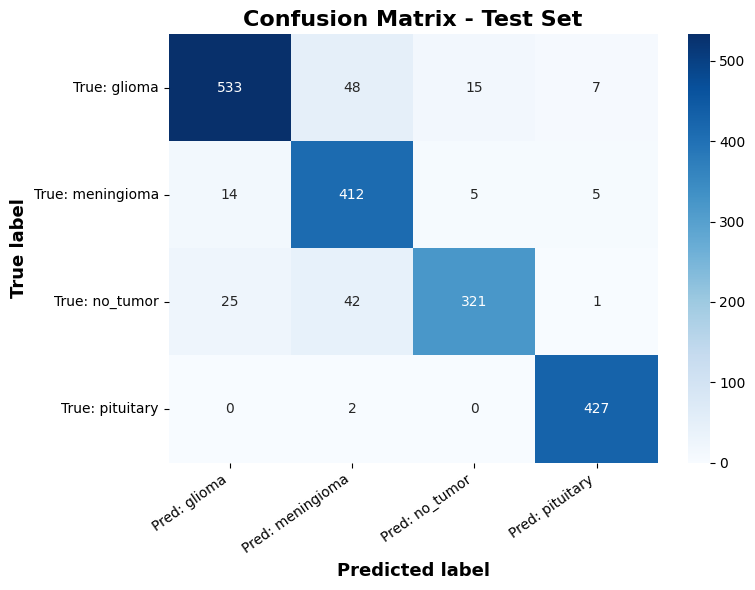

CSV mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_confusion_matrix_counts.csv
Kép mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_confusion_matrix_counts.png


In [15]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_df)

cm_csv = os.path.join(OUT_DIR, "test_confusion_matrix_counts.csv")
cm_df.to_csv(cm_csv, index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix - Test Set", fontsize=16, fontweight="bold")
plt.ylabel("True label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted label", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_png = os.path.join(OUT_DIR, "test_confusion_matrix_counts.png")
plt.savefig(cm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV mentve:", cm_csv)
print("Kép mentve:", cm_png)

,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,0.883914,0.079602,0.024876,0.011609
True: meningioma,0.032110,0.944954,0.011468,0.011468
True: no_tumor,0.064267,0.107969,0.825193,0.002571
True: pituitary,0.000000,0.004662,0.000000,0.995338


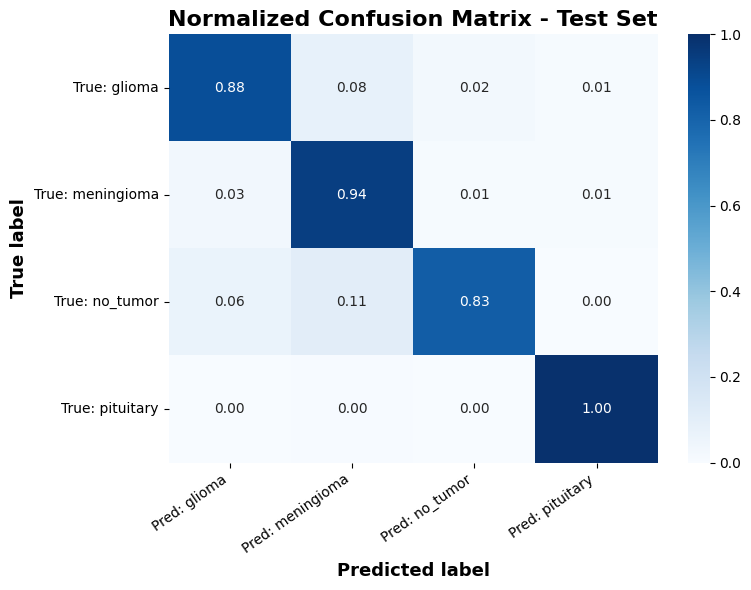

CSV mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_confusion_matrix_normalized.csv
Kép mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_confusion_matrix_normalized.png


In [16]:
# =========================
# NORMALIZÁLT CONFUSION MATRIX
# =========================

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_norm_df)

cm_norm_csv = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_csv, index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", cbar=True, vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix - Test Set", fontsize=16, fontweight="bold")
plt.ylabel("True label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted label", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_png = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.png")
plt.savefig(cm_norm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV mentve:", cm_norm_csv)
print("Kép mentve:", cm_norm_png)

In [17]:
# =========================
# KÉPENKÉNTI PREDIKCIÓK ÉS HIBÁK
# =========================

pred_rows = []

for i in range(len(y_true)):
    row = {
        "image_path": image_paths[i],
        "true_idx": int(y_true[i]),
        "pred_idx": int(y_pred[i]),
        "true_label": label_map_inv[int(y_true[i])],
        "predicted_label": label_map_inv[int(y_pred[i])],
        "correct": bool(y_true[i] == y_pred[i]),
        "confidence": float(np.max(y_prob[i]))
    }
    for j, cname in enumerate(CLASS_NAMES):
        row[f"prob_{cname}"] = float(y_prob[i][j])
    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)
display(pred_df.head(20))

pred_csv = os.path.join(OUT_DIR, "test_predictions_per_image.csv")
pred_df.to_csv(pred_csv, index=False)
print("Predikciók mentve:", pred_csv)

wrong_df = pred_df[pred_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values(by="confidence", ascending=False)

print("Hibás predikciók száma:", len(wrong_df), "/", len(pred_df))
display(wrong_df.head(50))

wrong_csv = os.path.join(OUT_DIR, "test_misclassified_images.csv")
wrong_df.to_csv(wrong_csv, index=False)
print("Hibák mentve:", wrong_csv)

,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
0,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.997070,0.997070,0.002569,0.000069,0.000315
1,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000365,0.000063,0.000082
2,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.998535,0.998535,0.000515,0.000046,0.000782
3,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000347,0.000120,0.000110
4,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999023,0.999023,0.000726,0.000026,0.000138
5,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999023,0.999023,0.000739,0.000012,0.000357
6,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999023,0.999023,0.000265,0.000017,0.000484
7,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999023,0.999023,0.000708,0.000142,0.000107
8,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.935059,0.935059,0.042786,0.007553,0.014816
9,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000201,0.000026,0.000063


Predikciók mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_predictions_per_image.csv
Hibás predikciók száma: 164 / 1857


,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
1075,/content/drive/MyDrive/Brain MRI/dataset/Test/...,2,1,no_tumor,meningioma,False,1.000000,0.000042,1.000000,0.000104,0.000093
1373,/content/drive/MyDrive/Brain MRI/dataset/Test/...,2,1,no_tumor,meningioma,False,0.999512,0.000049,0.999512,0.000107,0.000091
213,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.998047,0.001284,0.998047,0.000507,0.000243
487,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.997559,0.000445,0.997559,0.001784,0.000114
1391,/content/drive/MyDrive/Brain MRI/dataset/Test/...,2,1,no_tumor,meningioma,False,0.997559,0.000407,0.997559,0.002068,0.000073
1095,/content/drive/MyDrive/Brain MRI/dataset/Test/...,2,1,no_tumor,meningioma,False,0.997559,0.001933,0.997559,0.000362,0.000033
521,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.997070,0.001824,0.997070,0.000824,0.000325
486,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.996582,0.000247,0.996582,0.003025,0.000013
519,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.996094,0.000797,0.996094,0.001316,0.001835
557,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.994629,0.000666,0.004436,0.994629,0.000239


Hibák mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/test_misclassified_images.csv


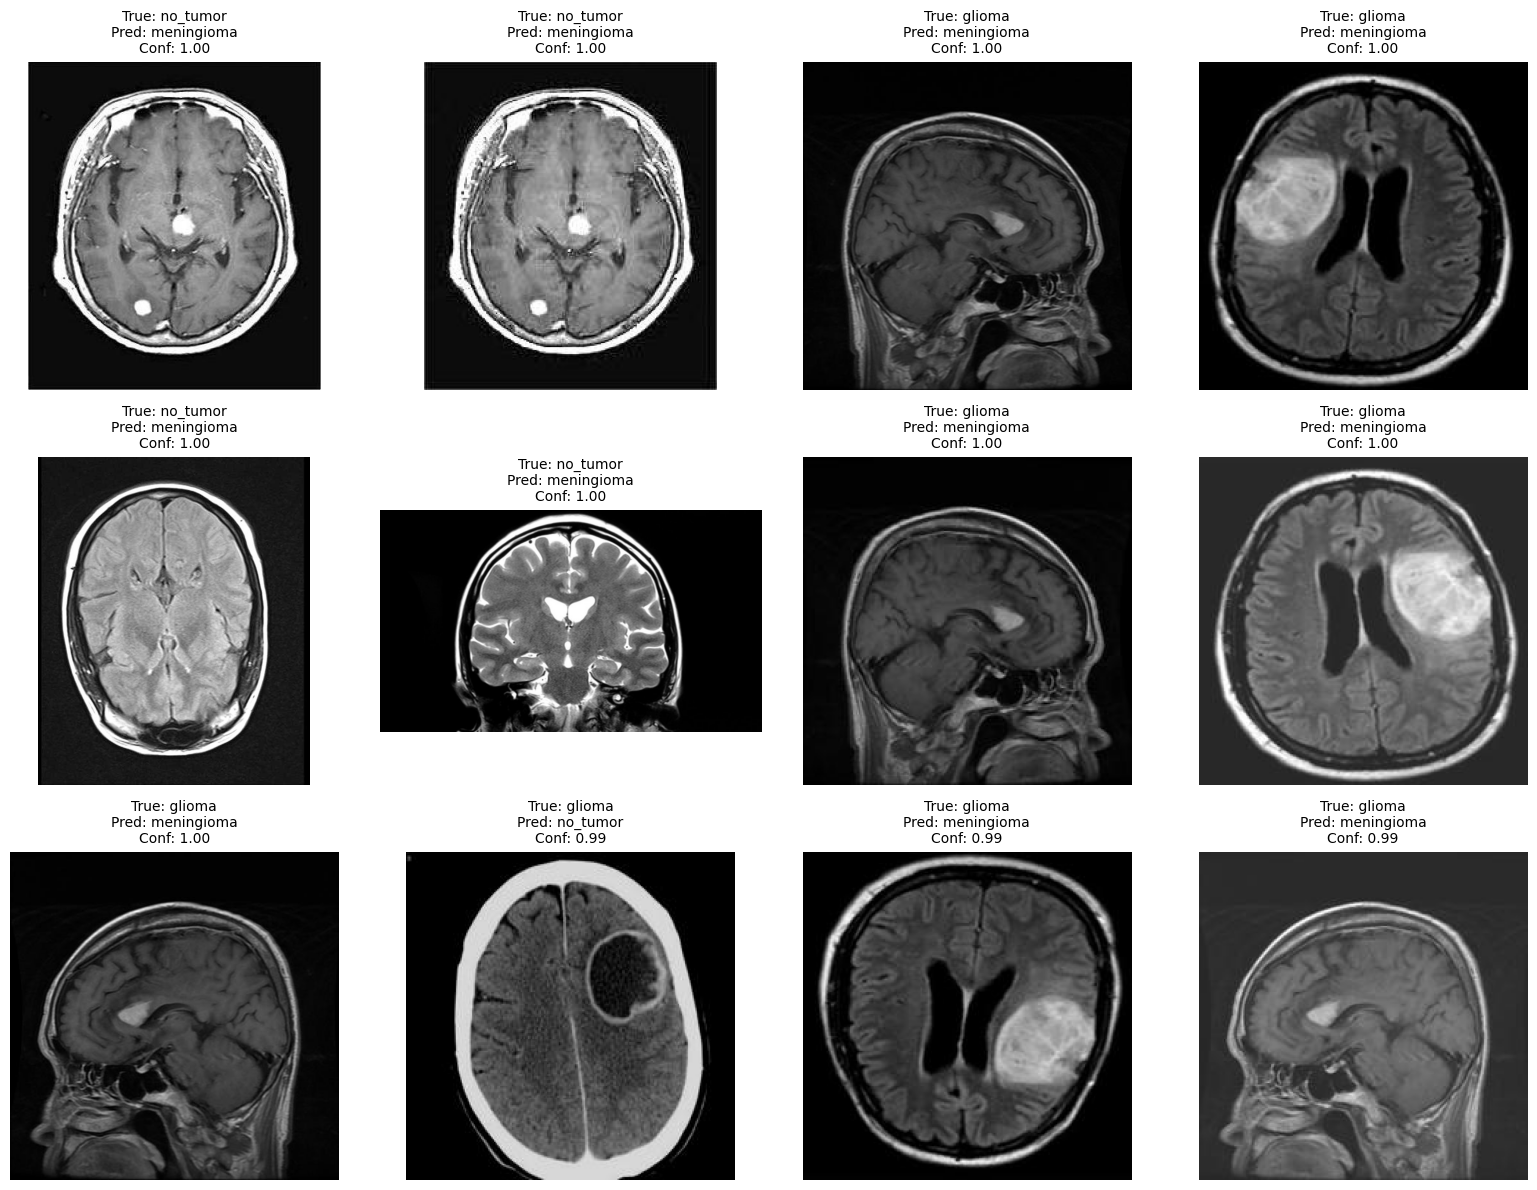

Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL/misclassified_examples.png


In [18]:
# =========================
# HIBÁS PÉLDÁK VIZUALIZÁLÁSA
# =========================

def show_misclassified_examples(wrong_df, max_images=12):
    if len(wrong_df) == 0:
        print("Nincs hibás klasszifikáció.")
        return

    sample_df = wrong_df.head(max_images).copy()
    n = len(sample_df)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "misclassified_examples.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Mentve:", out_path)

show_misclassified_examples(wrong_df, max_images=12)

In [19]:
# =========================
# ÖSSZES EREDMÉNY
# =========================

print("Kiértékelés kész.")
print("Eredmények mappája:", OUT_DIR)

print("\nLétrehozott fájlok:")
for f in sorted(os.listdir(OUT_DIR)):
    print(" -", f)

Kiértékelés kész.
Eredmények mappája: /content/drive/MyDrive/Brain MRI/FNO_clas/DenseNet121_Fourier_final/test_evaluation_FULL

Létrehozott fájlok:
 - misclassified_examples.png
 - test_classification_report.csv
 - test_confusion_matrix_counts.csv
 - test_confusion_matrix_counts.png
 - test_confusion_matrix_normalized.csv
 - test_confusion_matrix_normalized.png
 - test_file_list.csv
 - test_misclassified_images.csv
 - test_predictions_per_image.csv
 - test_results_table.csv
 - test_summary_metrics.csv
